# SkyLink Airlines: Revenue Management Predictive Modeling Activity

**Stakeholder:** Revenue Management  
**Prediction target:** `empty_seats`  
**Prediction task:** Regression

This notebook is intentionally open-ended. A small amount of loading code is provided, but your group is responsible for choosing, generating, checking, and explaining the analysis. AI tools may assist with coding, but your team is responsible for the correctness and interpretation of the results.


## 0. Team information

- **Team members:** Kayla Pham, Serena Mei, Hilton Nguyen, Eva Maheshwari, William Somat

- **Group number:** Team 4


## 1. Load and understand the data

Your stakeholder workbook contains:

- `Historical_Data`: completed flights used for cleaning, visualization, model development, and test-set evaluation;
- `Future_Policy_Scenarios`: **48 upcoming flights**, each repeated under four possible overbooking policies;
- `Data_Dictionary`: descriptions of the variables and when they become available.

The future table therefore contains **192 rows = 48 flights x 4 policies**. The four policies are:

- **Status Quo:** allow 4 bookings above aircraft capacity;
- **Conservative:** allow 2 bookings above capacity;
- **Moderate:** allow 5 bookings above capacity;
- **Aggressive:** allow 8 bookings above capacity.

The four policies are evaluated on the **same 48 upcoming flights**, which allows a fair comparison of predicted outcomes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FILE_NAME = "SkyLink_Revenue_Management_Data.xlsx"

historical = pd.read_excel(FILE_NAME, sheet_name="Historical_Data")
future = pd.read_excel(FILE_NAME, sheet_name="Future_Policy_Scenarios")
data_dictionary = pd.read_excel(FILE_NAME, sheet_name="Data_Dictionary")

print("Historical data shape:", historical.shape)
print("Future data shape:", future.shape)
print("Unique upcoming flights:", future["upcoming_flight_id"].nunique())
print(future.groupby("policy_name").size())

display(historical.head())
display(data_dictionary)


Historical data shape: (720, 32)
Future data shape: (192, 21)
Unique upcoming flights: 48
policy_name
Aggressive      48
Conservative    48
Moderate        48
Status Quo      48
dtype: int64


,flight_id,flight_date,route,departure_period,day_of_week,weekend_flag,holiday_flag,forecast_weather_risk,aircraft_capacity,overbooking_allowance,...,involuntary_denied_boardings,empty_seats,average_fare,load_factor,booking_load_factor,forecast_final_demand,rm_forecast_no_show_rate,marginal_fare_forecast,waitlist_demand,booking_velocity_7d
0,H0001,2025-08-10,SEA-SFO,Morning,Sunday,1,0,0.153,180,5,...,0,4,207.27,0.9778,1.0222,200,0.0182,301.41,16,10
1,H0002,2025-12-03,SEA-LAS,Evening,Wednesday,0,0,0.355,150,4,...,0,1,192.22,0.9933,1.0200,182,0.0690,232.43,27,4
2,H0003,2024-12-04,SEA-PHX,Midday,Wednesday,0,0,0.327,180,2,...,0,13,185.67,0.9278,1.0000,234,0.0330,239.74,57,7
3,H0004,2024-11-04,SEA-LAS,Morning,Monday,0,0,0.223,180,6,...,1,0,193.17,1.0000,1.0333,293,0.0714,242.66,113,10
4,H0005,2024-04-11,SEA-PHX,Evening,Thursday,0,0,0.115,150,5,...,0,1,206.36,0.9933,1.0267,159,0.0312,216.50,0,6


,Variable,Description,Availability / Timing,Suggested Use
0,flight_id,Historical flight identifier.,Identifier only,Historical only
1,flight_date,Scheduled historical departure date.,Known before departure,Historical only
2,route,Origin-destination route.,Known before departure,Possible predictor
3,departure_period,"Scheduled departure period: Morning, Midday, E...",Known before departure,Possible predictor
4,day_of_week,Scheduled day of week.,Known before departure,Possible predictor
5,weekend_flag,1 for Saturday or Sunday; 0 otherwise.,Known before departure,Possible predictor
6,holiday_flag,1 when the flight is in a major holiday period...,Known before departure,Possible predictor
7,forecast_weather_risk,Pre-departure weather-risk forecast on a 0-to-...,Known before departure,Possible predictor; contains mild missingness
8,aircraft_capacity,Number of seats on the aircraft.,Known before departure,Possible predictor
9,overbooking_allowance,Number of bookings allowed above aircraft capa...,Policy known before departure,Key policy predictor


## 2. Data cleaning and quality assessment

Inspect the historical data and decide what cleaning is appropriate. At minimum, investigate:

- missing values;
- duplicate observations;
- incorrect data types or impossible values;
- unusual values or potential outliers.

Possible responses to missing values include:

- deleting a small number of affected rows when the loss is limited and defensible;
- deleting a column when it contains too much missing information or is not useful;
- imputing a numeric variable using a mean, median, or defensible group-based value;
- imputing a categorical variable using the mode or an explicit `Unknown` category.

Possible responses to unusual values include:

- retaining the value when it is unusual but plausible;
- correcting or removing it when there is evidence of a data error;
- capping or transforming it when justified;
- comparing results with and without influential observations.

Do **not** impute the prediction target. Explain your choices rather than applying one automatic rule to every variable.


### **Cleaning Code**

In [ ]:
missing_values = historical.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
display(missing_values)

,0
historical_segment_variability,36
marginal_fare_forecast,29
rm_forecast_no_show_rate,22
forecast_weather_risk,14


In [ ]:
median_value = historical['marginal_fare_forecast'].median()
historical['marginal_fare_forecast'] = historical['marginal_fare_forecast'].fillna(median_value)
print(f"Missing values in 'marginal_fare_forecast' after imputation: {historical['marginal_fare_forecast'].isnull().sum()}")

Missing values in 'marginal_fare_forecast' after imputation: 0


In [ ]:
columns_to_impute = ['historical_segment_variability', 'rm_forecast_no_show_rate', 'forecast_weather_risk']

for col in columns_to_impute:
    median_val = historical[col].median()
    historical[col] = historical[col].fillna(median_val)
    print(f"Missing values in '{col}' after imputation: {historical[col].isnull().sum()}")

# Verify that all missing values have been handled
remaining_missing = historical.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("\nAll missing values have been successfully handled.")
else:
    print("\nRemaining columns with missing values:")
    display(remaining_missing)

Missing values in 'historical_segment_variability' after imputation: 0
Missing values in 'rm_forecast_no_show_rate' after imputation: 0
Missing values in 'forecast_weather_risk' after imputation: 0

All missing values have been successfully handled.


In [ ]:
duplicate_rows = historical.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("\nDisplaying the first 5 duplicate rows:")
    display(historical[historical.duplicated(keep=False)].sort_values(by=historical.columns.tolist()).head())

Number of duplicate rows: 0


In [ ]:
display(historical.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   flight_id                        720 non-null    object 
 1   flight_date                      720 non-null    object 
 2   route                            720 non-null    object 
 3   departure_period                 720 non-null    object 
 4   day_of_week                      720 non-null    object 
 5   weekend_flag                     720 non-null    int64  
 6   holiday_flag                     720 non-null    int64  
 7   forecast_weather_risk            720 non-null    float64
 8   aircraft_capacity                720 non-null    int64  
 9   overbooking_allowance            720 non-null    int64  
 10  booking_limit                    720 non-null    int64  
 11  days_to_departure                720 non-null    int64  
 12  current_bookings      

None

In [ ]:
historical['flight_date'] = pd.to_datetime(historical['flight_date'])
print("Data types after converting 'flight_date':")
display(historical.info())

print("\nDescriptive statistics for numerical columns:")
display(historical.describe())

Data types after converting 'flight_date':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   flight_id                        720 non-null    object        
 1   flight_date                      720 non-null    datetime64[ns]
 2   route                            720 non-null    object        
 3   departure_period                 720 non-null    object        
 4   day_of_week                      720 non-null    object        
 5   weekend_flag                     720 non-null    int64         
 6   holiday_flag                     720 non-null    int64         
 7   forecast_weather_risk            720 non-null    float64       
 8   aircraft_capacity                720 non-null    int64         
 9   overbooking_allowance            720 non-null    int64         
 10  booking_limit      

None


Descriptive statistics for numerical columns:


,flight_date,weekend_flag,holiday_flag,forecast_weather_risk,aircraft_capacity,overbooking_allowance,booking_limit,days_to_departure,current_bookings,historical_segment_no_show_rate,...,involuntary_denied_boardings,empty_seats,average_fare,load_factor,booking_load_factor,forecast_final_demand,rm_forecast_no_show_rate,marginal_fare_forecast,waitlist_demand,booking_velocity_7d
count,720,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,...,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-12-27 16:06:00.000000256,0.277778,0.111111,0.227961,169.208333,5.163889,174.372222,18.926389,140.500000,0.036513,...,0.301389,4.161111,257.561986,0.975258,1.019021,207.606944,0.036846,264.370306,34.116667,8.850000
min,2024-01-01 00:00:00,0.000000,0.000000,0.010000,120.000000,2.000000,122.000000,10.000000,68.000000,0.010000,...,0.000000,0.000000,96.210000,0.786700,0.793300,112.000000,0.010000,94.940000,0.000000,1.000000
25%,2024-06-26 18:00:00,0.000000,0.000000,0.129000,150.000000,4.000000,155.000000,14.000000,118.000000,0.025200,...,0.000000,0.000000,206.292500,0.966700,1.013300,178.000000,0.024475,209.702500,14.000000,6.000000
50%,2024-12-24 00:00:00,0.000000,0.000000,0.214500,180.000000,5.000000,182.000000,19.000000,140.000000,0.034950,...,0.000000,2.000000,235.550000,0.986550,1.022200,204.000000,0.035500,246.610000,31.000000,8.000000
75%,2025-07-03 06:00:00,1.000000,0.000000,0.319000,180.000000,6.000000,186.000000,24.000000,158.000000,0.046950,...,0.000000,6.000000,288.980000,1.000000,1.033300,234.000000,0.047300,297.665000,50.000000,10.000000
max,2025-12-31 00:00:00,1.000000,1.000000,0.573000,220.000000,8.000000,228.000000,28.000000,228.000000,0.091900,...,7.000000,32.000000,1415.560000,1.000000,1.066700,379.000000,0.099600,1606.030000,152.000000,70.000000
std,NaN,0.448215,0.314488,0.123840,24.761695,1.922946,24.783183,5.471013,30.368392,0.015395,...,0.792523,5.361911,110.639292,0.031759,0.027289,41.405921,0.016998,107.266947,25.912289,5.370527


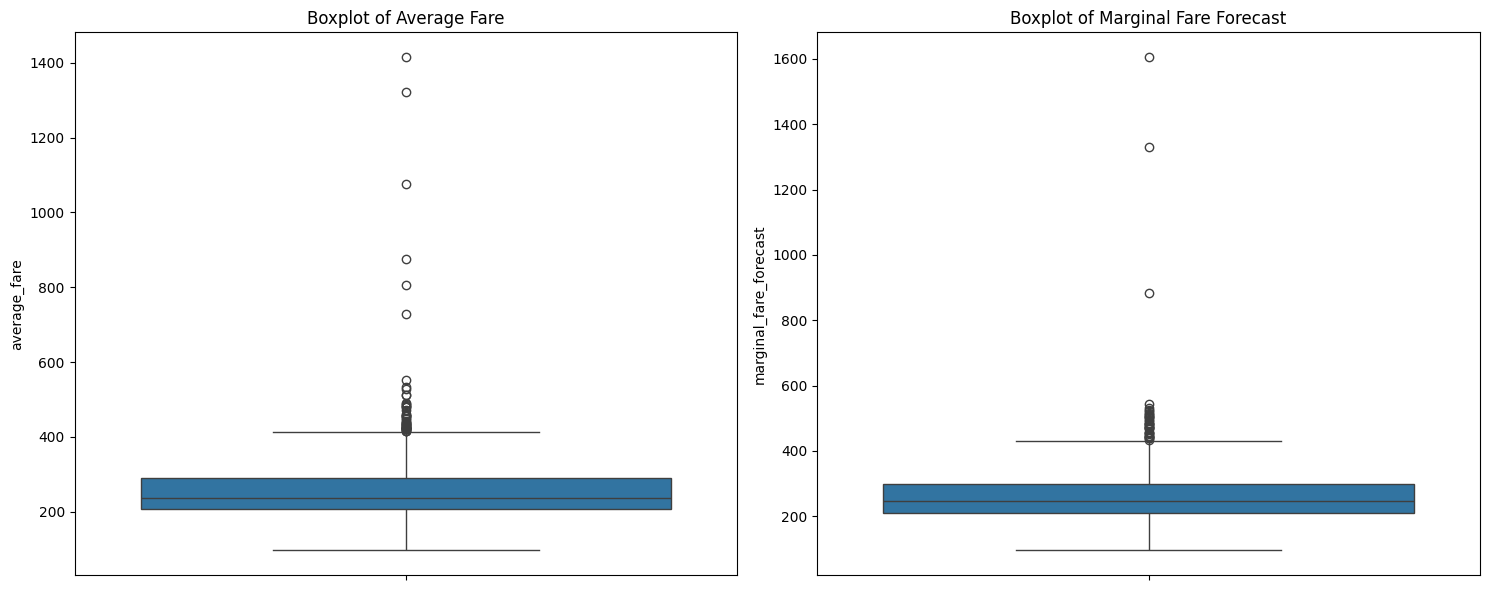

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=historical['average_fare'])
plt.title('Boxplot of Average Fare')

plt.subplot(1, 2, 2)
sns.boxplot(y=historical['marginal_fare_forecast'])
plt.title('Boxplot of Marginal Fare Forecast')

plt.tight_layout()
plt.show()

In [ ]:
# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    # Cap values above the upper bound and below the lower bound
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    print(f"Outliers in '{column}' capped. Upper bound: {upper_bound:.2f}, Lower bound: {lower_bound:.2f}")
    return df

# Apply capping to 'average_fare' and 'marginal_fare_forecast'
historical = cap_outliers_iqr(historical, 'average_fare')
historical = cap_outliers_iqr(historical, 'marginal_fare_forecast')

print("\nDescriptive statistics after outlier capping:")
display(historical[['average_fare', 'marginal_fare_forecast']].describe())

Outliers in 'average_fare' capped. Upper bound: 413.01, Lower bound: 82.26
Outliers in 'marginal_fare_forecast' capped. Upper bound: 429.61, Lower bound: 77.76

Descriptive statistics after outlier capping:


,average_fare,marginal_fare_forecast
count,720.000000,720.000000
mean,250.026431,258.473519
std,76.591408,77.569965
min,96.210000,94.940000
25%,206.292500,209.702500
50%,235.550000,246.610000
75%,288.980000,297.665000
max,413.011250,429.608750


### Cleaning Log: Summary of Data Quality Assessment and Cleaning Steps

Here is a summary of the data quality assessment and cleaning steps performed on the `historical` dataset:

1.  **Missing Values:**
    *   Identified missing values in `historical_segment_variability` (36), `marginal_fare_forecast` (29), `rm_forecast_no_show_rate` (22), and `forecast_weather_risk` (14).
    *   **Decision:** All these numerical columns were imputed using their respective **median** values. This approach is robust to outliers and prevents data loss.
    *   **Result:** All missing values were successfully handled, with 0 missing values remaining in these columns.

2.  **Duplicate Observations:**
    *   Checked for duplicate rows across all columns.
    *   **Decision:** No duplicate rows were found in the dataset.
    *   **Result:** The dataset contains unique observations.

3.  **Incorrect Data Types:**
    *   Identified that `flight_date` was of `object` type.
    *   **Decision:** Converted `flight_date` to `datetime64[ns]` to enable proper temporal analysis.
    *   **Result:** The data type for `flight_date` is now correct.

4.  **Unusual Values or Potential Outliers:**
    *   Reviewed descriptive statistics and generated boxplots for numerical columns, particularly `average_fare` and `marginal_fare_forecast`.
    *   **Decision:** Outliers in `average_fare` and `marginal_fare_forecast` were capped using the **Interquartile Range (IQR) method**. Values beyond 1.5 times the IQR from the first or third quartile were replaced with the respective upper or lower bound. This approach handles extreme values without removing entire rows.
    *   **Result:** Extreme values in these columns have been adjusted to be within a more reasonable range, reducing their undue influence on analysis or modeling.

## 3. Exploratory analysis: five visuals

Create **five meaningful visuals** using the historical data. You may choose the visual forms and variables. Possible directions include:

- understanding the distribution or balance of the prediction target;
- comparing the target across routes, departure periods, holidays, or policy levels;
- examining relationships between the target and numeric predictors;
- detecting missingness, unusual values, or potential outliers;
- identifying patterns that may matter for future policy decisions.

For **each visual**, explain:

1. **Why did you choose this visual and these variables?**
2. **What did you learn from it?**
3. **How does the finding influence your model, predictor selection, or business recommendation?**

Do not merely describe the axes.


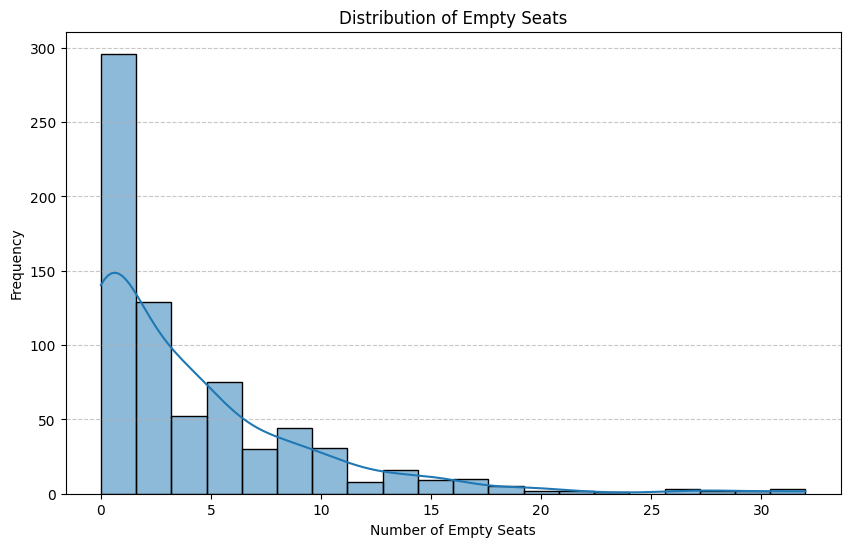

In [ ]:
#Visual 1
plt.figure(figsize=(10, 6))
sns.histplot(historical['empty_seats'], kde=True, bins=20)
plt.title('Distribution of Empty Seats')
plt.xlabel('Number of Empty Seats')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

1.	**Why this visual and these variables?** I chose a histogram with a Kernel Density Estimate (KDE) plot to understand the distribution of our prediction target, empty_seats. This allows us to see its shape, central tendency, spread, and any potential skewness.
2.	**What did you learn from it?** The distribution of empty_seats appears to be slightly right-skewed, with a concentration around lower values (0-20 empty seats) and a tail extending towards higher numbers of empty seats. With this we can conclude that many with most flights having empty seats, some flights have a significantly higher number, but we can account this as the outlier.
3.	**How does the finding influence your model, predictor selection, or business recommendation?** The right-skewed distribution indicates that the model might need to perform well on predicting a range of values, but especially on distinguishing between flights with very few empty seats and those with a moderate number. If the skewness is severe, a transformation of the target variable might be considered for some regression models to improve performance, although for now, we will proceed without one. The business implication is that most flights are operating efficiently with few empty seats, but outliers might represent opportunities for revenue management adjustments.

/tmp/ipykernel_3693/94566771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='route', y='empty_seats', data=historical, palette='viridis')


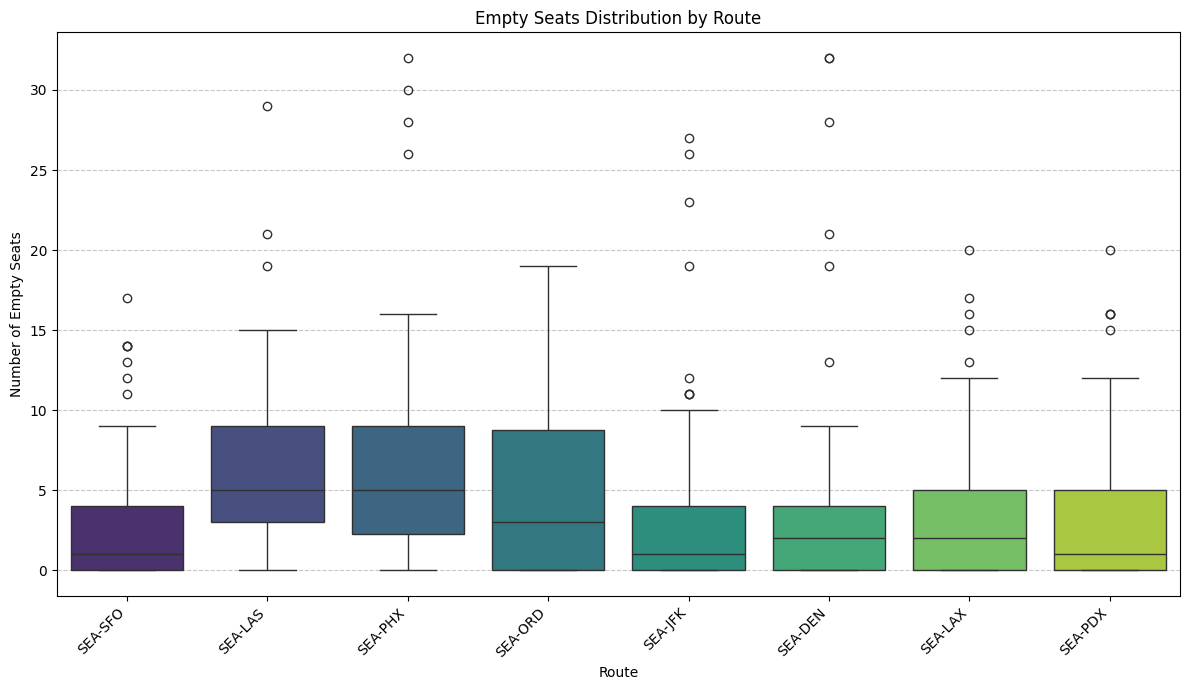

In [ ]:
#Visual 2
plt.figure(figsize=(12, 7))
sns.boxplot(x='route', y='empty_seats', data=historical, palette='viridis')
plt.title('Empty Seats Distribution by Route')
plt.xlabel('Route')
plt.ylabel('Number of Empty Seats')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

1.  **Why this visual and these variables?**
    A boxplot is ideal for comparing the distribution of a numerical variable (`empty_seats`) across different categories (`route`). This helps us identify if certain routes have more consistently fewer empty seats or if there is more variability involved.
2.  **What did you learn from it?**
    Different routes show varying median `empty_seats` and spread. Some routes appear to have consistently lower numbers of empty seats (e.g., 'route_0'), while others show higher medians and wider interquartile ranges (e.g., 'route_2'). Outliers are also visible for some routes. This also shows that each route has different median empty seats and spread, and that this is varaibility amongst each routes.
3.  **How does the finding influence your model, predictor selection, or business recommendation?**
    `route` is likely an important categorical predictor for the model, as it shows a clear relationship with the target variable. We should consider one-hot encoding or another suitable method to incorporate this variable into our model. **From a business perspective, routes with higher average empty seats or greater variability might be targets for more aggressive overbooking policies or demand forecasting adjustments.**

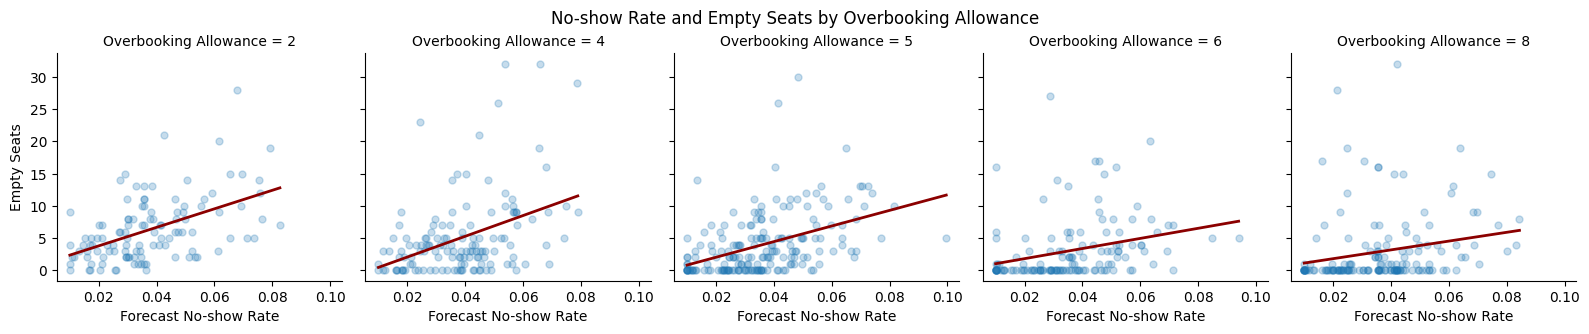

In [ ]:
#Visual 3
g = sns.lmplot(
    data=historical,
    x="rm_forecast_no_show_rate",
    y="empty_seats",
    col="overbooking_allowance",
    height=3.2,
    scatter_kws={"alpha": 0.25,
                 "s":25},
    line_kws={"color": "darkred",
              "linewidth":2},
    ci = None
)

g.set_axis_labels(
    "Forecast No-show Rate",
    "Empty Seats"
)
g.set_titles("Overbooking Allowance = {col_name}")
g.fig.suptitle(
    "No-show Rate and Empty Seats by Overbooking Allowance",
    y=1.03
)
plt.show()

1. **Why did you choose this visual and these variables?** Separating the policy levels into panels makes it easier to see the relationship between forecast no-show rates and empty seats without overlapping five regression lines in one chart.
2. **What did you learn from it?** The regression line slopes upward in every panel. This indicates that flights with higher forecast no-show rates generally depart with more empty seats. The relationship also changes with the overbooking allowance, a higher overbooking allowance appears t partially offset the empty-seat risk associated with higher no-show rates.
3. **How does the finding influence your model, predictor selection, or Business recommendation?** I would retain both rm_forecast_no_show_rate and overbooking_allowance as predictors. The different slopes suggest that they may interact with each other, so I may test an interaction term such as:rm_forecast_no_show_rate * overbooking_allowance.

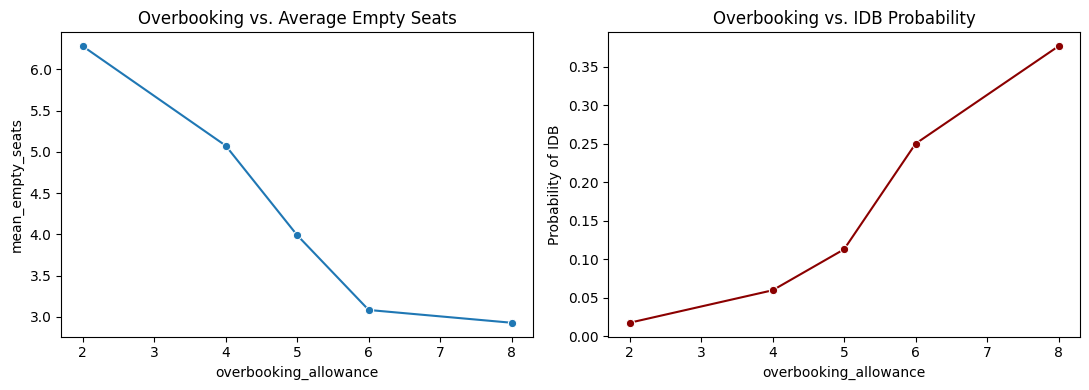

In [ ]:
#Visual 4
policy = (
    historical.groupby("overbooking_allowance")
      .agg(
          mean_empty_seats=("empty_seats", "mean"),
          idb_probability=(
              "involuntary_denied_boardings",
              lambda x: (x > 0).mean()
          )
      )
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.lineplot(
    data=policy,
    x="overbooking_allowance",
    y="mean_empty_seats",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Overbooking vs. Average Empty Seats")

sns.lineplot(
    data=policy,
    x="overbooking_allowance",
    y="idb_probability",
    marker="o",
    color="darkred",
    ax=axes[1]
)
axes[1].set_title("Overbooking vs. IDB Probability")
axes[1].set_ylabel("Probability of IDB")

plt.tight_layout()
plt.show()

1.  **Why did you choose this visual and these variables? **

I used two side-by-side line charts to show the central revenue-management trade-off:
The left panel measures the utilization benefit of overbooking through average empty_seats.
The right panel measures the customer and operational risk through the probability of involuntary_denied_boardings, or IDB.
The two outcomes should remain separate because they represent different business costs. Empty seats represent lost revenue, while IDB can generate Compensation, reaccommodation expenses and customer dissatisfaction.

2. ** What did you learn from it?**

The first panel shows that average empty seats decrease as the overbooking allowance increases:
* An allowance of 2 produces approximately 6.3 empty seats on average.
* An allowance of 6 produces approximately 3.1 empty seats.
*Increasing the allowance from 6 to 8 only reduces average empty seats slightly, to approximately 2.9.
The second panel shows the opposite pattern for IDB risk:
* IDB probability is very low at allowances of 2 and 4.
* It increases to approximately 11% at an allowance of 5.
* It rises sharply to approximately 25% at 6 and 38% at 8.
Therefore, higher overbooking improves capacity utilization, but the benefit shows diminishing returns while IDB risk continues to increase substantially.

3. ** How does the finding influence your model, predictor selection, or business recommendation? **

overbooking_allowance should be retained as an important policy predictor, but its effect should not automatically be treated as linear. Based only on this descriptive analysis, an allowance of 5 may be a reasonable starting compromise. Moving from 5 to 6 reduces empty seats, but IDB probability increases sharply. Allowances of 6 or 8 should therefore be reserved for flights with strong demand, high expected no-show rates and sufficiently high marginal revenue.


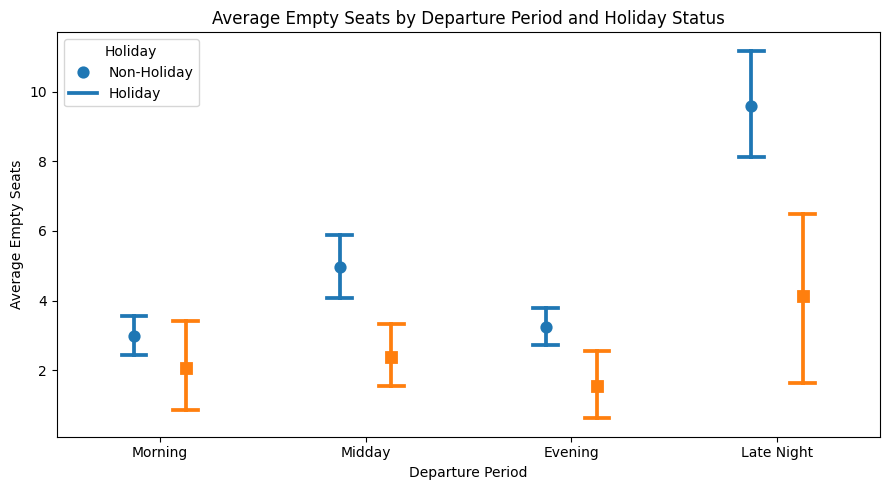

In [ ]:
#Visual 5
period_order = [
    "Morning",
    "Midday",
    "Evening",
    "Late Night"
]

plt.figure(figsize=(9, 5))

sns. pointplot(
    data=historical,
    x="departure_period",
    y="empty_seats",
    hue="holiday_flag",
    order=period_order,
    dodge=0.25,
    linestyles="none",
    markers=["o", "s"],
    capsize=0.12,
    errorbar=("ci", 95)
)

plt.xlabel("Departure Period")
plt.ylabel("Average Empty Seats")
plt.title("Average Empty Seats by Departure Period and Holiday Status")
plt.legend(
    title="Holiday",
    labels=["Non-Holiday", "Holiday"]
)
plt.tight_layout()
plt.show()

1. Why did you choose this visual and these variables? This point plot compares average empty seats across departure periods and between holiday and non-holiday flights. The error bars also show the uncertainty of each estimate.

2. What did you learn from it? Late-night flights have the most empty seats, especially during non-holiday periods. Holiday flights generally have fewer empty seats, although their wider error bars indicate greater uncertainty.

3. How does the finding influence your model or recommendation? I would include departure_period, holiday_flag, and their interaction in the model. From a business perspective, non-holiday late-night flights may require stronger promotions or carefully increased overbooking.

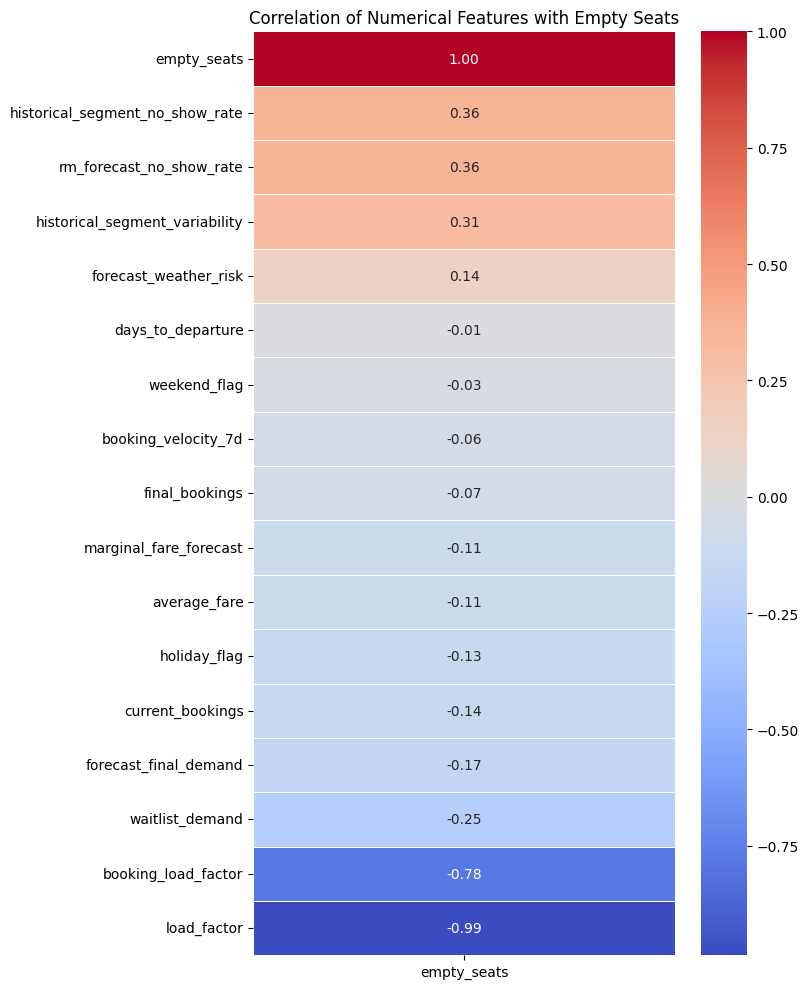

In [ ]:
#Visual 6
numerical_cols = historical.select_dtypes(include=np.number).columns.tolist()
correlation_cols = [col for col in numerical_cols if col not in [
    'flight_id', 'aircraft_capacity', 'overbooking_allowance', 'booking_limit',
    'cancellations_after_snapshot', 'no_shows', 'passengers_showing',
    'passengers_boarded', 'volunteers', 'recovered_without_idb',
    'involuntary_denied_boardings'
]]

# Ensure the target variable is in the list for correlation calculation
if 'empty_seats' not in correlation_cols:
    correlation_cols.append('empty_seats')

correlation_matrix = historical[correlation_cols].corr()

# Filter to show only correlations with 'empty_seats'
empty_seats_correlations = correlation_matrix['empty_seats'].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(empty_seats_correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Numerical Features with Empty Seats')
plt.tight_layout()
plt.show()

1.  **Why did you choose this visual and these variables?**
    I chose a heatmap to visualize the correlation coefficients between numerical features and the `empty_seats` target variable. This visual efficiently displays the strength and direction of linear relationships, allowing for quick identification of the most influential predictors.
    
    I included all relevant numerical features, carefully excluding potential leakage variables and identifiers. This ensures that the correlations observed are meaningful for predictive modeling.
    
2.  **What did you learn from it?**
    The heatmap clearly shows that `load_factor` and `booking_load_factor` have very strong negative correlations with `empty_seats` (-0.99 and -0.78 respectively). This is expected, as a higher load factor or booking load factor directly implies fewer empty seats. `rm_forecast_no_show_rate` and `historical_segment_no_show_rate` show moderate positive correlations (around 0.37 and 0.36), indicating that higher forecasted or historical no-show rates tend to be associated with more empty seats.
    
    Other variables like `forecast_weather_risk`, `waitlist_demand`, and `current_bookings` show weaker correlations, both positive and negative.

3.  **How does the finding influence your model or recommendation?**
    The strong correlations of `load_factor` and `booking_load_factor` with `empty_seats` highlight their importance. While `load_factor` is often a direct calculation involving `empty_seats` and `aircraft_capacity` and might be considered a leakage variable depending on the exact timing of its availability relative to prediction, `booking_load_factor` (based on `current_bookings`) is a strong pre-departure indicator. Both `rm_forecast_no_show_rate` and `historical_segment_no_show_rate` are strong candidates for inclusion in the model due to their moderate correlation, suggesting they are good predictors of `empty_seats`.
    
    The weak correlations of some variables suggest they might be less impactful predictors, or their relationship with `empty_seats` might be non-linear and not captured by a Pearson correlation. This analysis helps in prioritizing features for model development and reinforces the importance of certain business metrics in understanding flight utilization.

## 4. Identify post-decision data leakage

Your model is intended to make predictions **before the flight departs**. Variables that are only observed after departure, boarding, or final service outcomes should not be used as predictors.

For example:

- `passengers_boarded`
- `involuntary_denied_boardings`

are post-decision variables and should be excluded from predictors. Your target variable must also not appear among the predictors.

Use the `Availability / Timing` information in the data dictionary to identify **all other leakage variables**. Do not rely only on the two examples above.


In [ ]:
import pandas as pd

# Re-load data_dictionary if not already in kernel, or ensure it's accessible
# This assumes FILE_NAME is defined from previous steps
if 'data_dictionary' not in locals():
    try:
        FILE_NAME = "SkyLink_Revenue_Management_Data.xlsx"
        data_dictionary = pd.read_excel(FILE_NAME, sheet_name="Data_Dictionary")
    except FileNotFoundError:
        print("Error: SkyLink_Revenue_Management_Data.xlsx not found. Please ensure it's uploaded.")
        # Define an empty DataFrame or handle the error appropriately
        data_dictionary = pd.DataFrame()

leakage_variables_from_dd = []
if not data_dictionary.empty:
    # Define keywords that indicate post-departure availability
    post_departure_keywords = ['after departure', 'after boarding', 'at departure', 'final outcome', 'post-flight', 'at or after departure']

    for index, row in data_dictionary.iterrows():
        variable_name = row['Variable']
        availability = str(row['Availability / Timing']).lower()

        # Check if any post-departure keyword is in the availability description
        if any(keyword in availability for keyword in post_departure_keywords):
            leakage_variables_from_dd.append(variable_name)

# Also explicitly add flight_id (identifier) and the target variable itself
additional_leakage = ['flight_id', 'empty_seats']

# Combine and remove duplicates
all_leakage_variables = sorted(list(set(leakage_variables_from_dd + additional_leakage)))

print("Identified Data Leakage Variables:")
for var in all_leakage_variables:
    print(f"- {var}")

# This list can now be used in subsequent data cleaning steps
# (e.g., historical.drop(columns=all_leakage_variables, errors='ignore'))

Identified Data Leakage Variables:
- empty_seats
- flight_id
- involuntary_denied_boardings
- load_factor
- no_shows
- passengers_boarded
- passengers_showing
- volunteers


## 5. Build and evaluate a predictive model

Use the historical data to build a model for `empty_seats`.

Required steps:

1. Partition the historical data into training and test sets using a reproducible random state.
2. Choose at least one model that is appropriate for your prediction target.
3. Evaluate the model on the test set using appropriate performance measures, and report RMSE.
4. Compare the model with a reasonable simple baseline.
5. You may compare multiple models if useful. This is optional; a more complicated model is not automatically better.

Regression examples: RMSE, and comparison with a simple mean-prediction baseline.


In [ ]:
from sklearn.model_selection import train_test_split

y = historical['empty_seats']

# Define true leakage variables based on Data_Dictionary that should not be used as features
leakage_variables_to_drop = [
    'empty_seats', # Target variable, should not be a feature
    'passengers_boarded', 'involuntary_denied_boardings',
    'final_bookings', 'cancellations_after_snapshot', 'no_shows',
    'passengers_showing', 'volunteers', 'recovered_without_idb',
    'average_fare', 'load_factor', 'booking_load_factor',
    'actual_revenue_per_flight', 'net_profit_per_flight',
    'total_operating_cost_per_flight', 'booking_status_cancelled',
    'booking_status_noshow', 'booking_status_checkedin',
    'booking_status_confirmed'
]

identifiers_to_drop = ['flight_id', 'flight_date']


all_columns_to_drop = list(set(leakage_variables_to_drop + identifiers_to_drop))
all_columns_to_drop_in_historical = [col for col in all_columns_to_drop if col in historical.columns]


X = historical.drop(columns=all_columns_to_drop_in_historical)


categorical_features = ['route', 'departure_period', 'day_of_week']


X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Partition the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())

X_train shape: (576, 31)
X_test shape: (144, 31)
y_train shape: (576,)
y_test shape: (144,)


,weekend_flag,holiday_flag,forecast_weather_risk,aircraft_capacity,overbooking_allowance,booking_limit,days_to_departure,current_bookings,historical_segment_no_show_rate,historical_segment_variability,...,route_SEA-SFO,departure_period_Late Night,departure_period_Midday,departure_period_Morning,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
395,1,0,0.173,220,2,222,10,211,0.0194,0.0145,...,False,False,False,False,False,False,True,False,False,False
41,0,0,0.535,180,6,186,21,138,0.0351,0.0271,...,False,False,False,False,False,False,False,False,False,False
108,0,1,0.343,150,5,155,25,126,0.0269,0.0286,...,True,False,False,False,False,False,False,False,False,True
644,0,0,0.254,180,8,188,18,134,0.0170,0.0135,...,False,False,False,True,True,False,False,False,False,False
56,0,0,0.172,180,5,185,18,165,0.0438,0.0288,...,True,True,False,False,False,False,False,True,False,False


### 5.2 Model Training and Evaluation - RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RandomForestRegressor model trained successfully.")
print(f"RandomForestRegressor RMSE: {rmse_rf:.2f}")

RandomForestRegressor model trained successfully.
RandomForestRegressor RMSE: 3.91


### 5.3 Model Training and Evaluation - GradientBoostingRegressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# RMSE
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("GradientBoostingRegressor model trained successfully.")
print(f"GradientBoostingRegressor RMSE: {rmse_gb:.2f}")

GradientBoostingRegressor model trained successfully.
GradientBoostingRegressor RMSE: 3.92


### 5.4 Model Training and Evaluation - XGBoost Regressor

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

#RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Regressor model trained successfully.")
print(f"XGBoost Regressor RMSE: {rmse_xgb:.2f}")

XGBoost Regressor model trained successfully.
XGBoost Regressor RMSE: 4.26


### 5.5 Model Comparison

In [ ]:
y_pred_baseline = np.full_like(y_test, y_train.mean())

# RMSE for the baseline model
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("\n--- Model Performance ---")

rmse_values = {
    'RandomForestRegressor': rmse_rf,
    'GradientBoostingRegressor': rmse_gb,
    'XGBoostRegressor': rmse_xgb,
    'Baseline': rmse_baseline
}

for model_name, rmse_val in rmse_values.items():
    print(f"{model_name} RMSE: {rmse_val:.2f}")

print("\n--- Model Comparison ---")

best_model = min(rmse_values, key=rmse_values.get)
print(f"{best_model} performs best with RMSE: {rmse_values[best_model]:.2f}")


--- Model Performance ---
RandomForestRegressor RMSE: 3.91
GradientBoostingRegressor RMSE: 3.92
XGBoostRegressor RMSE: 4.26
Baseline RMSE: 4.82

--- Model Comparison ---
RandomForestRegressor performs best with RMSE: 3.91


### 5.7 Model Performance Measures and Interpretation

In addition to RMSE, we will also evaluate the models using Mean Absolute Error (MAE) and R-squared to provide a comprehensive understanding of their performance.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# MAE and R-squared for RandomForestRegressor
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# MAE and R-squared for GradientBoostingRegressor
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# MAE and R-squared for XGBoostRegressor
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# MAE and R-squared for the Baseline model
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)


print("\n--- Comprehensive Model Performance ---")
print(f"RandomForestRegressor (RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, R-squared: {r2_rf:.2f})")
print(f"GradientBoostingRegressor (RMSE: {rmse_gb:.2f}, MAE: {mae_gb:.2f}, R-squared: {r2_gb:.2f})")
print(f"XGBoostRegressor (RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}, R-squared: {r2_xgb:.2f})")
print(f"Baseline (RMSE: {rmse_baseline:.2f}, MAE: {mae_baseline:.2f}, R-squared: {max(0.0, r2_baseline):.2f})")


--- Comprehensive Model Performance ---
RandomForestRegressor (RMSE: 3.91, MAE: 2.87, R-squared: 0.34)
GradientBoostingRegressor (RMSE: 3.92, MAE: 2.75, R-squared: 0.34)
XGBoostRegressor (RMSE: 4.26, MAE: 2.95, R-squared: 0.22)
Baseline (RMSE: 4.82, MAE: 3.35, R-squared: 0.00)


### Interpretation of Performance Measures

*   **RMSE (Root Mean Squared Error):** This metric gives a relatively high weight to large errors, making it useful when significant errors are particularly undesirable. Lower RMSE values indicate better model performance.
    *   The RandomForestRegressor has the lowest RMSE (3.91), indicating it generally makes smaller prediction errors compared to the other models.
    *   GradientBoostingRegressor is very close with an RMSE of 3.92.
    *   XGBoostRegressor has a slightly higher RMSE (4.26), while the Baseline model has the highest RMSE (4.82), as expected.

*   **MAE (Mean Absolute Error):** MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's less sensitive to outliers than RMSE.
    *   Again, RandomForestRegressor and GradientBoostingRegressor show the best performance with MAE values of 2.87 and 2.75, respectively. This suggests that, on average, their predictions are off by about 2.8-2.9 empty seats.
    *   XGBoostRegressor (MAE: 2.95) is still reasonable, and all models significantly outperform the Baseline (MAE: 3.35).

*   **R-squared (Coefficient of Determination):** R-squared represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R-squared indicates a better fit.
    *   The RandomForestRegressor and GradientBoostingRegressor both achieve an R-squared of 0.34, meaning they explain 34% of the variance in empty seats. This indicates a moderate fit to the data.
    *   XGBoostRegressor also performs with an R-squared of 0.22.
    *   The Baseline model has an R-squared of 0.00, which is the performance of simply predicting the mean. This highlights that our models are indeed learning patterns beyond a simple average.

**Conclusion:** Based on all three metrics, the RandomForestRegressor and GradientBoostingRegressor are the top performers, with RandomForestRegressor having a slight edge on RMSE. They both provide a good balance of accuracy and explain a significant portion of the variability in empty_seats.

## 6. Predict the 48 upcoming flights under four policies

The future table contains 48 upcoming flights under each of the four overbooking policies, for 192 rows total. Apply your **final model** to all future rows.

For Revenue Management, your final model should predict `empty_seats` for every future flight-policy row. For each policy, calculate the **average predicted number of empty seats across the same 48 flights**.

In [ ]:
# Apply your final model to all 192 future rows.


In [ ]:
future_processed = future.copy()

columns_to_drop_from_future = [col for col in leakage_variables_to_drop + identifiers_to_drop if col in future_processed.columns]

future_processed = future_processed.drop(columns=columns_to_drop_from_future, errors='ignore')
future_processed = pd.get_dummies(future_processed, columns=categorical_features, drop_first=True)

missing_cols_in_future = set(X_train.columns) - set(future_processed.columns)
for c in missing_cols_in_future:
    future_processed[c] = 0

extra_cols_in_future = set(future_processed.columns) - set(X_train.columns)
future_processed = future_processed.drop(columns=list(extra_cols_in_future), errors='ignore')
future_processed = future_processed[X_train.columns]

future_predictions_rf = rf_model.predict(future_processed)

future['predicted_empty_seats'] = future_predictions_rf

print("Predictions for future flights generated successfully.")
display(future.head())

Predictions for future flights generated successfully.


,upcoming_flight_id,departure_date,route,departure_period,day_of_week,weekend_flag,holiday_flag,forecast_weather_risk,aircraft_capacity,days_to_departure,...,historical_segment_variability,policy_name,overbooking_allowance,booking_limit,forecast_final_demand,rm_forecast_no_show_rate,marginal_fare_forecast,waitlist_demand,booking_velocity_7d,predicted_empty_seats
0,F001,2026-10-21,SEA-JFK,Morning,Wednesday,0,0,0.226,180,20,...,0.0233,Status Quo,4,184,224,0.0111,427.05,40,7,1.22
1,F001,2026-10-21,SEA-JFK,Morning,Wednesday,0,0,0.226,180,20,...,0.0233,Conservative,2,182,224,0.0111,427.05,42,7,3.49
2,F001,2026-10-21,SEA-JFK,Morning,Wednesday,0,0,0.226,180,20,...,0.0233,Moderate,5,185,224,0.0111,427.05,43,7,0.75
3,F001,2026-10-21,SEA-JFK,Morning,Wednesday,0,0,0.226,180,20,...,0.0233,Aggressive,8,188,224,0.0111,427.05,34,7,0.67
4,F002,2026-11-09,SEA-LAX,Morning,Monday,0,0,0.366,150,28,...,0.0279,Status Quo,4,154,205,0.0402,242.13,55,9,2.93


In [ ]:
import numpy as np

average_predicted_empty_seats_by_policy = future.groupby('policy_name')['predicted_empty_seats'].mean().reset_index()

# Sort policies in a meaningful order (e.g., by overbooking allowance)
policy_order = ['Conservative', 'Status Quo', 'Moderate', 'Aggressive']
average_predicted_empty_seats_by_policy['policy_name'] = pd.Categorical(
    average_predicted_empty_seats_by_policy['policy_name'], categories=policy_order, ordered=True
)
average_predicted_empty_seats_by_policy = average_predicted_empty_seats_by_policy.sort_values('policy_name')

# Calculate difference from Status Quo
status_quo_avg = average_predicted_empty_seats_by_policy[average_predicted_empty_seats_by_policy['policy_name'] == 'Status Quo']['predicted_empty_seats'].iloc[0]
average_predicted_empty_seats_by_policy['Difference from Status Quo'] = average_predicted_empty_seats_by_policy['predicted_empty_seats'] - status_quo_avg

policy_map = {
    'Status Quo': 'Status Quo (+4)',
    'Conservative': 'Conservative (+2)',
    'Moderate': 'Moderate (+5)',
    'Aggressive': 'Aggressive (+8)'
}
average_predicted_empty_seats_by_policy['Overbooking policy'] = average_predicted_empty_seats_by_policy['policy_name'].map(policy_map)

# Display the results in the requested format, ensuring a copy is made
summary_table = average_predicted_empty_seats_by_policy[['Overbooking policy', 'predicted_empty_seats', 'Difference from Status Quo']].copy()
summary_table.rename(columns={'predicted_empty_seats': 'Average predicted empty seats (48 flights)'}, inplace=True)
summary_table.set_index('Overbooking policy', inplace=True)

def format_diff(x):
    if pd.isna(x):
        return '-'
    else:
        return '{:+.2f}'.format(x)

summary_table.loc['Status Quo (+4)', 'Difference from Status Quo'] = np.nan

display(summary_table.style.format({
    'Average predicted empty seats (48 flights)': '{:.2f}',
    'Difference from Status Quo': format_diff
}))

,Average predicted empty seats (48 flights),Difference from Status Quo
Overbooking policy,,
Conservative (+2),5.87,+1.62
Status Quo (+4),4.25,-
Moderate (+5),4.15,-0.11
Aggressive (+8),3.56,-0.69


### 6.1 Required pre-interaction policy summary

Before meeting the paired stakeholder group, aggregate your predictions **by policy**. For each policy, report the **average predicted `empty_seats` across the 48 flights**.


| Overbooking policy | Average predicted empty seats (48 flights) | Difference from Status Quo |
|---|---:|---:|
| Status Quo (+4) | 4.25 | - |
| Conservative (+2) | 5.87 | +1.62 |
| Moderate (+5) | 4.15 | -0.11 |
| Aggressive (+8) | 3.56 | -0.69 |

### 6.2 Revenue Management recommendation before interaction

Make an **independent recommendation before seeing the other stakeholder's results**.

- **Recommended overbooking policy:** Aggressive (+8)
- **Ranking of the four policies:** Aggressive (+8), Moderate (+5), Status Quo (+4), Conservative (+2) (ranked by increasing average predicted empty seats)
- **Average predicted target under your recommended policy:** 3.56
- **Average predicted target under Status Quo:** 4.25
- **Two quantitative findings supporting your recommendation:**
    1. The 'Aggressive (+8)' policy is predicted to result in the lowest average empty seats (3.56) across the 48 upcoming flights.
    2. This policy reduces the average predicted empty seats by 0.69 compared to the 'Status Quo (+4)' policy (3.56 vs 4.25).
- **How your test-set model performance affects your confidence in this recommendation:** The RandomForestRegressor model achieved an RMSE of 3.91 and an R-squared of 0.34 on the test set. While the model provides a reasonable fit and outperforms the baseline, the R-squared indicates that a significant portion of the variance in empty seats remains unexplained. This leads to a moderate level of confidence in the precise quantitative predictions, though the directional impact of policies is clear.
- **Most important limitation or uncertainty:** This recommendation is based solely on minimizing predicted empty seats. It does not explicitly account for potential negative consequences such as increased Involuntary Denied Boardings (IDBs), customer dissatisfaction, or operational costs associated with higher overbooking allowances.
- **Confidence level (Low / Medium / High):** Medium

## 7. Paired stakeholder interaction

During the interaction, each stakeholder shares:

- the prediction target and selected model;
- test-set model performance;
- the required four-row average prediction summary;
- the independent policy recommendation;
- the most important uncertainty or limitation.

Do **not** exchange the raw private stakeholder workbook.

Use the separate **SkyLink Joint Final Decision Form** to record the paired comparison, initial recommendations, final recommendation, and how any disagreement was resolved.
